In [12]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path
import csv
import json
import subprocess
import re
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists() and REPO_ROOT.name == "experiments":
    REPO_ROOT = REPO_ROOT.parent
EXPERIMENTS_DIR = REPO_ROOT / "experiments"
SACHS_SUMMARY_CSV = EXPERIMENTS_DIR / "out" / "experiment1" / "sachs_summary.csv"
SACHS_RESPONSES_DIR = EXPERIMENTS_DIR / "responses" / "sachs"

def normalize_experiment1_rows(df):
    df = df.copy()
    m = df["prompt_style"].eq("cases")
    df.loc[m & df["model"].astype(str).str.contains("summary_joint", na=False), "prompt_style"] = "summary_joint"
    df.loc[m & df["model"].astype(str).str.contains("matrix", na=False), "prompt_style"] = "matrix"
    df.loc[m & df["model"].astype(str).str.contains("_anon_", na=False), "anonymize"] = 1
    df.loc[m & ~df["model"].astype(str).str.contains("_anon_", na=False), "anonymize"] = 0
    df["model"] = df["model"].astype(str).str.replace(
        r"^p\d+_(?:anon_)?(?:thinktags_)?(?:summary_joint|matrix)_(.+)$", r"\1", regex=True
    )
    df["model"] = df["model"].str.replace(r"^(.+)_sft$", r"\1 sft", regex=True)
    df.loc[df["model"].eq("sft"), "model"] = "Qwen3-4B-Thinking-2507 sft"
    df["method"] = df["prompt_style"].map({
        "summary_joint": "Summary-Joint",
        "matrix": "Tabular",
        "names_only": "Name-Only",
        "enco": "ENCO",
    })
    return df

# Display settings: do not abbreviate DataFrame output
pd.set_option("display.max_rows", None)        # show all rows
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", None)           # don't wrap to fit console width
pd.set_option("display.max_colwidth", None)    # don't truncate column contents


In [13]:
BASE_DIR = SACHS_RESPONSES_DIR
SUMMARY_CSV = BASE_DIR / "eval_summary.csv"

df = pd.read_csv(SUMMARY_CSV)

In [14]:
# sachs_df = pd.read_csv("./responses/sachs/eval_summary.csv")

In [15]:
from pathlib import Path
import json
import pandas as pd

root = Path("/u/chenyuen0103/ENCO/experiments/checkpoints/cd_descendants_stage1_sft_only")
rows = []

for p in sorted(root.glob("*/grpo/grpo_log/train_metrics.jsonl")):
    stage = p.parts[-4]
    with open(p) as f:
        logs = [json.loads(x) for x in f if x.strip()]
    if not logs:
        continue
    last = logs[-1]
    rows.append({
        "stage": stage,
        "global_step": last.get("global_step"),
        "reward": last.get("reward"),
        "fmt": last.get("rewards/cd_format_reward/mean"),
        "desc": last.get("rewards/cd_descendant_f1_reward/mean"),
        "pfmt": last.get("rewards/cd_descendant_answer_tail_partial_format_reward/mean"),
        "clipped_ratio": last.get("completions/clipped_ratio"),
        "mean_len": last.get("completions/mean_length"),
        "term_len": last.get("completions/mean_terminated_length"),
    })

df = pd.DataFrame(rows)
if df.empty:
    print("No GRPO metric logs found under", root)
else:
    display(df.sort_values("stage"))


,stage,global_step,reward,fmt,desc,pfmt,clipped_ratio,mean_len,term_len
0,02_stage_2_named_obs100_int10,58,None,None,None,None,None,None,None


In [16]:
import pandas as pd


s = pd.read_csv(SACHS_SUMMARY_CSV)

g = s[s["model"].astype(str).str.contains("grpo", case=False, na=False)].copy()

# fix misparsed GRPO rows
m = g["prompt_style"].eq("cases")
g.loc[m & g["model"].str.contains("summary_joint", na=False), "prompt_style"] = "summary_joint"
g.loc[m & g["model"].str.contains("matrix", na=False), "prompt_style"] = "matrix"
g.loc[m & g["model"].str.contains("_anon_", na=False), "anonymize"] = 1
g.loc[m & ~g["model"].str.contains("_anon_", na=False), "anonymize"] = 0
g.loc[m, "model"] = (
    g.loc[m, "model"]
      .str.replace(r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", "", regex=True)
)

g = g[g["evaluated"] == 1].copy()

# choose existing count columns
row_cols = [c for c in ["n_rows", "num_rows"] if c in g.columns]
valid_cols = [c for c in ["n_valid_rows", "valid_rows"] if c in g.columns]

cols = [
    "model","prompt_style","anonymize","obs_n","int_n",
    *row_cols, *valid_cols,
    "avg_f1","avg_shd","consensus_f1","consensus_shd"
]
cols = [c for c in cols if c in g.columns]

display(g[cols].sort_values(["model","prompt_style","anonymize","obs_n","int_n"]))

agg_spec = {
    "mean_avg_f1": ("avg_f1","mean"),
    "mean_avg_shd": ("avg_shd","mean"),
    "mean_cons_f1": ("consensus_f1","mean"),
    "mean_cons_shd": ("consensus_shd","mean"),
    "cells": ("avg_f1","count"),
}
if "n_rows" in g.columns:
    agg_spec["sum_n_rows"] = ("n_rows","sum")
elif "num_rows" in g.columns:
    agg_spec["sum_n_rows"] = ("num_rows","sum")

if "n_valid_rows" in g.columns:
    agg_spec["sum_n_valid_rows"] = ("n_valid_rows","sum")
elif "valid_rows" in g.columns:
    agg_spec["sum_n_valid_rows"] = ("valid_rows","sum")

agg = (
    g.groupby(["model","prompt_style","anonymize"], as_index=False)
     .agg(**agg_spec)
     .sort_values(["model","prompt_style","anonymize"])
)

display(agg)


,model,prompt_style,anonymize,obs_n,int_n,num_rows,valid_rows,avg_f1,avg_shd,consensus_f1,consensus_shd


,model,prompt_style,anonymize,mean_avg_f1,mean_avg_shd,mean_cons_f1,mean_cons_shd,cells,sum_n_rows,sum_n_valid_rows


In [17]:
summary_csv = SACHS_SUMMARY_CSV
df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()
df = normalize_experiment1_rows(df)

models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507", "Qwen3-4B-Thinking-2507 sft"]
display(df[df["model"].isin(models)][["model", "method", "anonymize", "obs_n", "int_n", "valid_rows", "num_rows", "avg_f1", "avg_shd"]].sort_values(["model", "method", "anonymize", "obs_n", "int_n"]))


,model,method,anonymize,obs_n,int_n,valid_rows,num_rows,avg_f1,avg_shd
0,Qwen3-4B-Thinking-2507,Name-Only,0,NaN,NaN,3,5,0.299349,19.0000
13,Qwen3-4B-Thinking-2507,Summary-Joint,0,0.0,200.0,0,5,NaN,NaN
16,Qwen3-4B-Thinking-2507,Summary-Joint,0,0.0,200.0,3,5,0.360494,18.0000
51,Qwen3-4B-Thinking-2507,Summary-Joint,0,5000.0,0.0,0,5,NaN,NaN
54,Qwen3-4B-Thinking-2507,Summary-Joint,0,5000.0,0.0,5,5,0.441112,14.8000
69,Qwen3-4B-Thinking-2507,Summary-Joint,0,5000.0,200.0,0,5,NaN,NaN
73,Qwen3-4B-Thinking-2507,Summary-Joint,0,5000.0,200.0,1,5,0.444444,15.0000
6,Qwen3-4B-Thinking-2507,Summary-Joint,1,0.0,200.0,0,5,NaN,NaN
9,Qwen3-4B-Thinking-2507,Summary-Joint,1,0.0,200.0,3,5,0.444444,15.0000
44,Qwen3-4B-Thinking-2507,Summary-Joint,1,5000.0,0.0,0,5,NaN,NaN


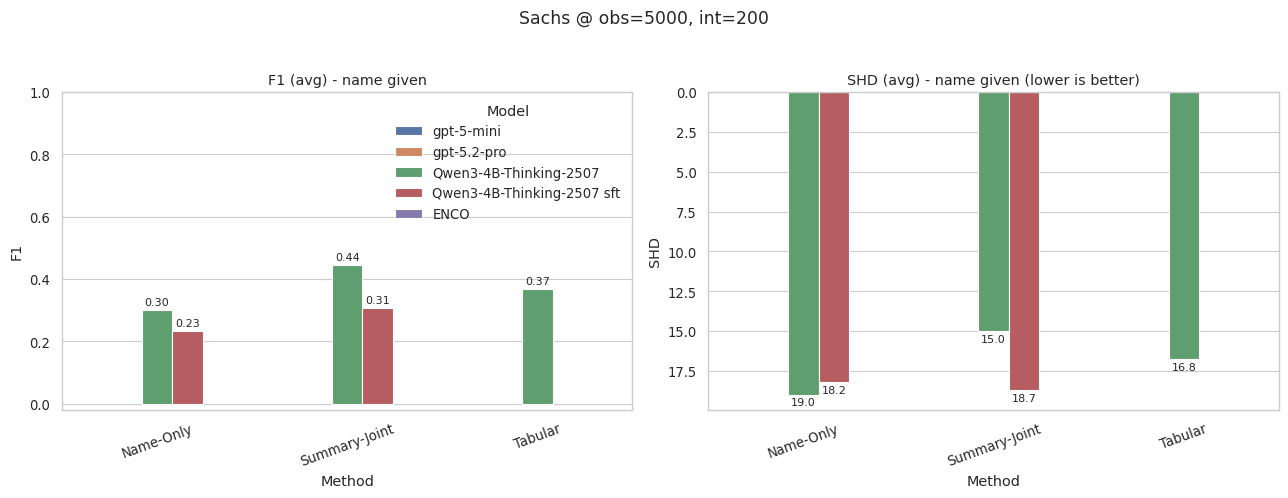

Saved: /u/chenyuen0103/ENCO/experiments/out/figures_pubready/sachs_obs5000_int200_name_given_avg_with_name_only.pdf


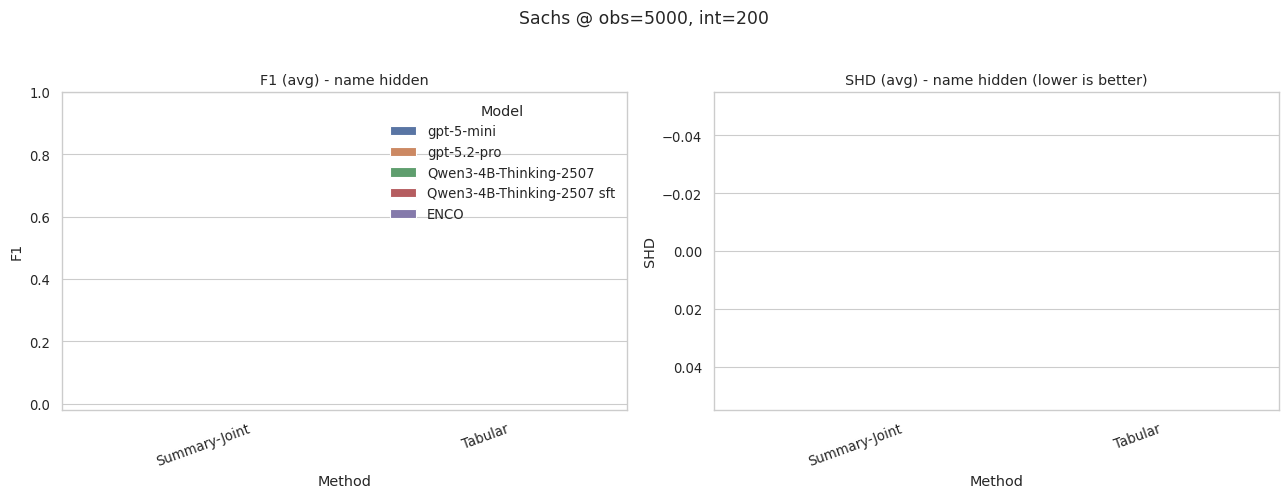

Saved: /u/chenyuen0103/ENCO/experiments/out/figures_pubready/sachs_obs5000_int200_name_hidden_avg_with_name_only.pdf


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv = SACHS_SUMMARY_CSV
obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507", "Qwen3-4B-Thinking-2507 sft"]
include_enco = True
out_dir = EXPERIMENTS_DIR / "out" / "figures_pubready"
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()
df = normalize_experiment1_rows(df)

# map methods
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])

# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    if sub.empty:
        print(f"No rows found for anon={anon_val}, obs={obs_target}, int={int_target}")
        continue

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)
